In [1]:
import sys
sys.path.append('..')
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
import cartopy
import cartopy.crs as ccrs
import colorcet as cc

from src.inversion_scripts.utils import sum_total_emissions

In [2]:
posterior_ds = xr.open_dataset('/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_2023_annual/inversion/posterior_ds.nc')
posterior = posterior_ds['EmisCH4_Total']

posterior

<xarray.DataArray 'EmisCH4_Total' (lat: 75, lon: 144)> Size: 86kB
[10800 values with dtype=float64]
Coordinates:
  * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
  * lat      (lat) float64 600B -60.0 -58.0 -56.0 -54.0 ... 82.0 84.0 86.0 88.0

In [3]:
state_vector_filepath = "/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_2022_annual/StateVector.nc"

state_vector = xr.open_dataset(state_vector_filepath)
state_vector_labels = state_vector["StateVector"]

# Identify the last element of the region of interest
last_ROI_element = int(
    np.nanmax(state_vector_labels.values)
)

# Define mask for region of interest
mask = state_vector_labels <= last_ROI_element

(-60, -10): [1.0614954601209377, 9.089402836970187, 13.817083943693582, 14.416933396150093, 18.59797476115712]
(-10, 10): [11.40576069666929, 11.026436380938094, 10.380051149611688, 10.063841452856565, 3.452668518547256]
(10, 30): [-15.499255623497618, -13.791073200266851, -27.20351685001279, -33.38704121615254, -29.7409642350287]
(30, 90): [11.631515183186366, 24.48588152557943, 5.658412427459638, 9.653264698507513, 12.20466992117278]


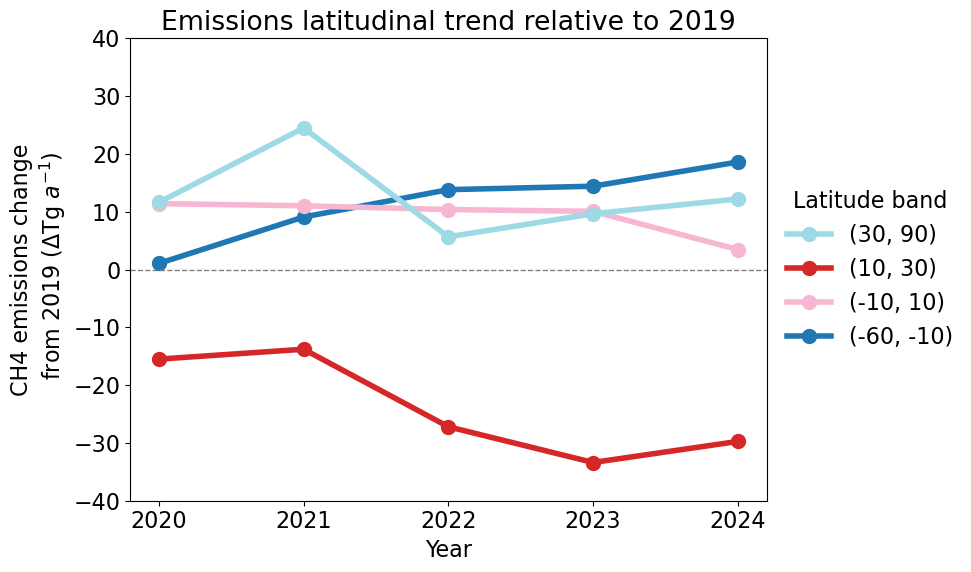

In [7]:
years_all = [2019, 2020, 2021, 2022, 2023, 2024]  # Includes 2019 for reference
years_plot = [2020, 2021, 2022, 2023, 2024]  # Only years to be plotted
lat_bands = {
    "(-60, -10)": (-60, -10),
    "(-10, 10)": (-10, 10),
    "(10, 30)": (10, 30),
    "(30, 90)": (30, 90)
}

lat_data = {band: {} for band in lat_bands}

for year in years_all:
    # Set directory
    if year == 2019:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual_ResMefix_2/inversion/posterior_ds.nc'
    else:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/posterior_ds.nc'
    posterior_ds = xr.load_dataset(path)
    posterior = posterior_ds["EmisCH4_Total"]
    areas = posterior_ds["AREA"]

    for band, (lat_min, lat_max) in lat_bands.items():
        # extract data within latitude band
        band_mask = (posterior["lat"] >= lat_min) & (posterior["lat"] < lat_max)
        emis_band = posterior.where(band_mask, drop=True)

        # calculate emissions
        # total_emissions = (emis_band * areas * 86400 * 365 * 1e-9).sum().item()
        total_emissions = sum_total_emissions(emis_band, areas, mask)
        lat_data[band][year] = total_emissions

# Calculate relative change compared to 2019
trend = {band: [] for band in lat_bands}
for band in lat_bands:
    ref_2019 = lat_data[band][2019]  # baseline 2019 emissions
    for year in years_plot:
        change = (lat_data[band][year] - ref_2019)
        trend[band].append(change)

# Plot
plt.rcParams.update({"font.size": 16})
fig, ax = plt.subplots(figsize=(10, 6))

num_colors = len(lat_bands)
cmap = plt.cm.get_cmap('tab20', num_colors)
all_colors = [cmap(i) for i in range(num_colors)]

# manually switch colors
idx_neg15_10 = list(lat_bands.keys()).index("(-10, 10)")
idx_10_35 = list(lat_bands.keys()).index("(10, 30)")
all_colors[idx_neg15_10], all_colors[idx_10_35] = all_colors[idx_10_35], all_colors[idx_neg15_10]

for i, (band, changes) in enumerate(trend.items()):
    print(f"{band}: {changes}")
    ax.plot(years_plot, changes, marker='o', markersize=10, linewidth=4, label=band, color=all_colors[i])

ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel("Year")
ax.set_ylabel("CH4 emissions change\n from 2019 ($\\Delta$Tg $a^{-1}$)")
ax.set_title("Emissions latitudinal trend relative to 2019")
ax.set_ylim(-40, 40)

# one handle per sector for legend and reverse order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title='Latitude band', loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

plt.xticks(years_plot)
plt.tight_layout()
plt.show()

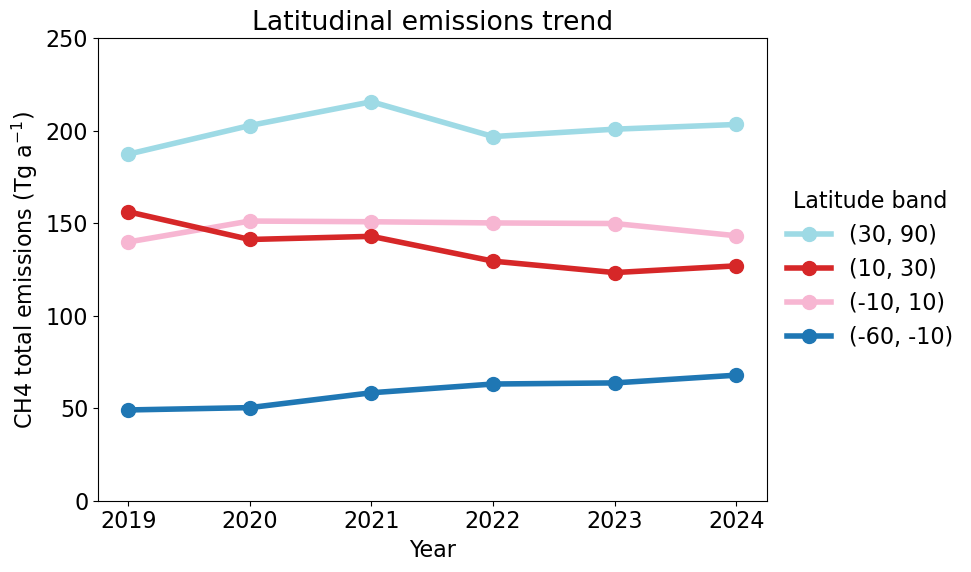

In [9]:
years_all = [2019, 2020, 2021, 2022, 2023, 2024]
lat_bands = {
    "(-60, -10)": (-60, -10),
    "(-10, 10)": (-10, 10),
    "(10, 30)": (10, 30),
    "(30, 90)": (30, 90)
}

lat_data = {band: {} for band in lat_bands}

for year in years_all:
    # Set directory
    if year == 2019:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_burnin/inversion/posterior_ds.nc'
    else:
        path = f'/n/holylfs06/LABS/jacob_lab2/Lab/mhe/Global_{year}_annual/inversion/posterior_ds.nc'
    posterior_ds = xr.load_dataset(path)
    posterior = posterior_ds["EmisCH4_Total"]
    areas = posterior_ds["AREA"]

    for band, (lat_min, lat_max) in lat_bands.items():
        # Extract data within latitude band
        band_mask = (posterior["lat"] >= lat_min) & (posterior["lat"] < lat_max)
        emis_band = posterior.where(band_mask, drop=True)

        # Calculate total emissions 
        total_emissions = sum_total_emissions(emis_band, areas, mask)
        lat_data[band][year] = total_emissions

# Instead of computing change relative to 2019, we create a new dictionary for the absolute values.
emissions_plot = {band: [] for band in lat_bands}
for band in lat_bands:
    for year in years_all:
        emissions_plot[band].append(lat_data[band][year])

# Plot
plt.rcParams.update({"font.size": 16})
fig, ax = plt.subplots(figsize=(10, 6))

num_colors = len(lat_bands)
cmap = plt.cm.get_cmap('tab20', num_colors)
all_colors = [cmap(i) for i in range(num_colors)]

# Manually switch colors if desired
idx_neg10_10 = list(lat_bands.keys()).index("(-10, 10)")
idx_10_30 = list(lat_bands.keys()).index("(10, 30)")
all_colors[idx_neg10_10], all_colors[idx_10_30] = all_colors[idx_10_30], all_colors[idx_neg10_10]

for i, (band, emissions) in enumerate(emissions_plot.items()):
    ax.plot(years_all, emissions, marker='o', markersize=10, linewidth=4, label=band, color=all_colors[i])

ax.set_xlabel("Year")
ax.set_ylabel("CH4 total emissions (Tg a$^{-1}$)")
ax.set_title("Latitudinal emissions trend")
ax.set_ylim(0, 250)
plt.xticks(years_all)

# one handle per sector for legend and reverse order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1],title='Latitude band', loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

plt.tight_layout()
plt.show()

In [12]:
south = np.array(emissions_plot["(-60, -10)"])
tropics = np.array(emissions_plot["(-10, 10)"])
mid_lat = np.array(emissions_plot["(10, 30)"])
north = np.array(emissions_plot["(30, 90)"])

# calculate the percent change from 2019 to 2024 for each latitude band
south_growth = ((south[-1] - south[0]) / south[0]) * 100
tropics_growth = ((tropics[-1] - tropics[0]) / tropics[0]) * 100
mid_lat_growth = ((mid_lat[-1] - mid_lat[0]) / mid_lat[0]) * 100
north_growth = ((north[-1] - north[0]) / north[0]) * 100

print(f"South: {south_growth:.1f}%")
print(f"Tropics: {tropics_growth:.1f}%")
print(f"Mid-lat: {mid_lat_growth:.1f}%")
print(f"North: {north_growth:.1f}%")

South: 38.3%
Tropics: 2.4%
Mid-lat: -18.7%
North: 8.6%


In [17]:
total_2019 = south[0] + tropics[0] + mid_lat[0] + north[0]
total_2024 = south[-1] + tropics[-1] + mid_lat[-1] + north[-1]

print(total_2019, total_2024)
print(north[0], north[-1])

print((north[-1]-north[0]) / (total_2024-total_2019) * 100)

532.5546248479154 541.573316663597
187.36190934842858 203.43407343344612
178.20948329858106


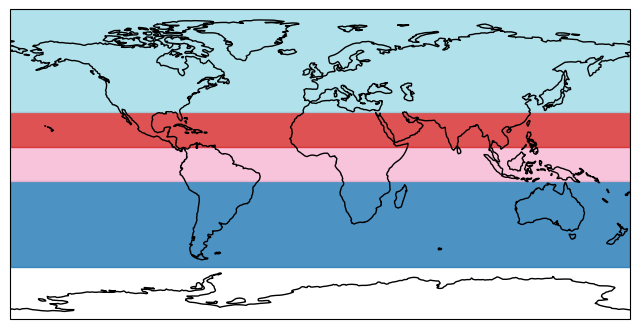

In [6]:
import matplotlib.patches as mpatches
fig, ax = plt.subplots(figsize=(8, 5), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_global()
ax.coastlines()

num_colors = len(lat_bands)
cmap = plt.cm.get_cmap('tab20', num_colors)
all_colors = [cmap(i) for i in range(num_colors)]

# manually switch colors
idx_neg15_10 = list(lat_bands.keys()).index("(-10, 10)")
idx_10_35 = list(lat_bands.keys()).index("(10, 30)")
all_colors[idx_neg15_10], all_colors[idx_10_35] = all_colors[idx_10_35], all_colors[idx_neg15_10]

# fill latitude bands on a global map
for i, ((band, (lat_min, lat_max)), color) in enumerate(zip(lat_bands.items(), all_colors)):
    # Create a rectangular polygon for each band
    rect = mpatches.Rectangle(
        xy=(-180, lat_min),  # Bottom-left corner
        width=360,  # Full width (from -180 to 180)
        height=lat_max - lat_min,  # Height from lat_min to lat_max
        transform=ccrs.PlateCarree(),
        color=color,
        alpha=0.8,
        label=band
    )
    ax.add_patch(rect)

plt.show()